# Grad-CAM with PyTorch + ResNet50

In [6]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [7]:
# Pretrained ResNet
model = models.resnet50(pretrained=True)
model.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 90.4MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
# Load example image
img_path = "https://pytorch.org/tutorials/_static/img/cat.jpg"
image = Image.open(requests.get(img_path, stream=True).raw).convert("RGB")

# Preprocess
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
input_tensor = transform(image).unsqueeze(0)  # shape [1,3,224,224]


In [9]:
# Hook for feature maps and gradients
gradients = []
features = []

def save_gradient(grad):
    gradients.append(grad)

def forward_hook(module, input, output):
    features.append(output)
    output.register_hook(save_gradient)

# Register hook on last conv layer (layer4[-1].conv3 for ResNet50)
target_layer = model.layer4[-1].conv3
target_layer.register_forward_hook(forward_hook)


In [10]:
# Forward pass
output = model(input_tensor)
pred_class = output.argmax().item()

# Backward for target class
model.zero_grad()
score = output[0, pred_class]
score.backward()


In [11]:
# Extract captured features and gradients
grads = gradients[0].mean(dim=(2,3), keepdim=True)  # average pooling
fmap = features[0]

# Weighted sum
cam = (grads * fmap).sum(dim=1).squeeze().detach().numpy()
cam = np.maximum(cam, 0)  # ReLU
cam = cv2.resize(cam, (224,224))
cam = cam - cam.min()
cam = cam / cam.max()


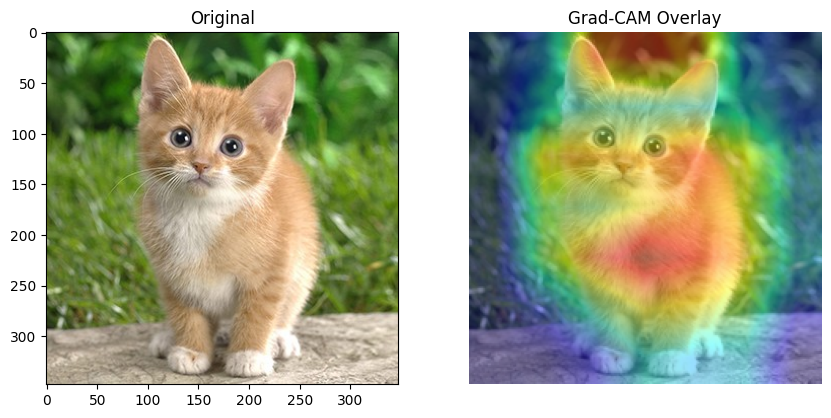

In [12]:
# Convert heatmap to color
heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# Overlay on original
overlay = np.array(image.resize((224,224)))
overlay = np.uint8(0.6*overlay + 0.4*heatmap)

# Plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()


# ViT attention visualization - rollout method

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

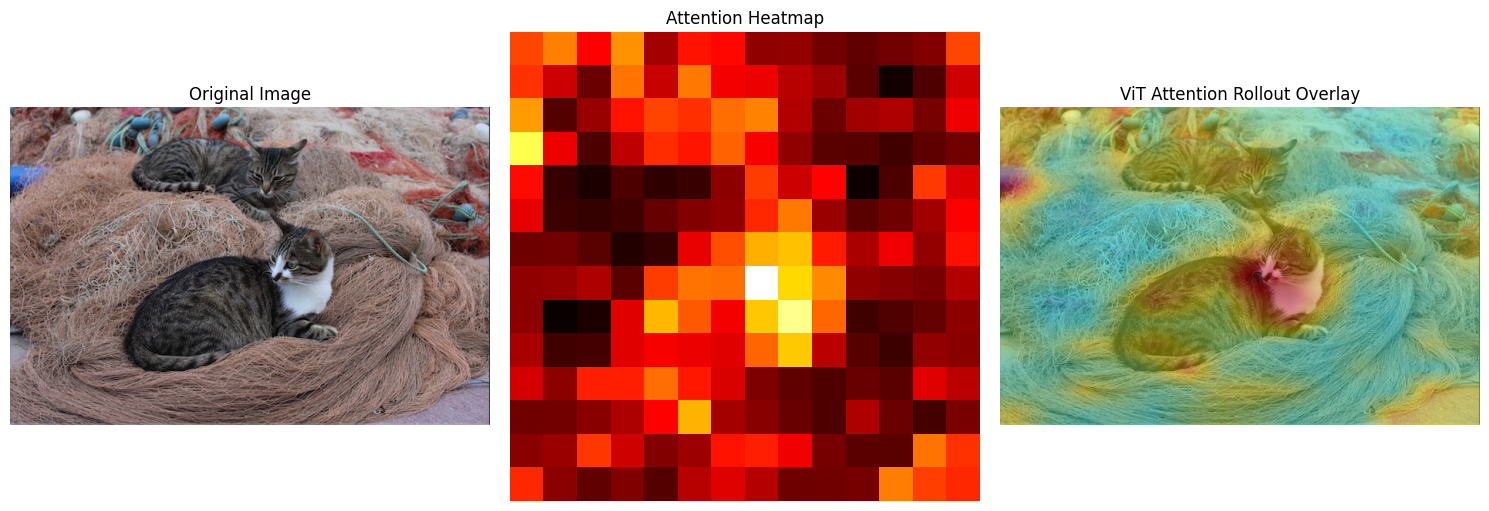

Model: google/vit-base-patch16-224
Image size: (622, 412)
Grid size: 14x14
Attention shape: (14, 14)
Max attention: 0.0078
Min attention: 0.0025


In [14]:
import torch
from transformers import ViTModel, ViTImageProcessor
from PIL import Image
import requests
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Load pretrained ViT
model_name = "google/vit-base-patch16-224"
model = ViTModel.from_pretrained(model_name, output_attentions=True)
processor = ViTImageProcessor.from_pretrained(model_name)

# Load image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
inputs = processor(images=image, return_tensors="pt")

# Forward pass with attention outputs
with torch.no_grad():  # Save memory
    outputs = model(**inputs)
attentions = outputs.attentions  # tuple of [layer, batch, heads, tokens, tokens]

# Rollout attention (average heads, multiply layers)
attn_mat = torch.stack(attentions)   # [layers, batch, heads, tokens, tokens]
attn_mat = attn_mat.mean(2)          # average over heads
attn_mat = attn_mat.squeeze(1)       # remove batch dim

# Add identity and normalize
residual = torch.eye(attn_mat.size(-1))
aug_attn = attn_mat + residual
aug_attn = aug_attn / aug_attn.sum(dim=-1, keepdim=True)

# Rollout: multiply layer by layer
joint_attn = aug_attn[0]
for i in range(1, aug_attn.size(0)):
    joint_attn = aug_attn[i] @ joint_attn

# CLS attention to patches
cls_attn = joint_attn[0, 1:]  # drop CLS itself
num_patches = cls_attn.size(0)
grid_size = int(num_patches ** 0.5)

# Verify grid size
assert grid_size * grid_size == num_patches, f"Expected square grid, got {num_patches} patches"

cls_attn = cls_attn.reshape(grid_size, grid_size).detach().numpy()

# Resize to image size and create heatmap
heatmap = cv2.resize(cls_attn / cls_attn.max(), (image.size[0], image.size[1]))
heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

# Convert BGR to RGB for matplotlib
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# Create overlay
overlay = cv2.addWeighted(np.array(image), 0.6, heatmap, 0.4, 0)

# Show results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(cls_attn, cmap='hot', interpolation='nearest')
plt.axis("off")
plt.title("Attention Heatmap")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.axis("off")
plt.title("ViT Attention Rollout Overlay")

plt.tight_layout()
plt.show()

# Print some debug info
print(f"Model: {model_name}")
print(f"Image size: {image.size}")
print(f"Grid size: {grid_size}x{grid_size}")
print(f"Attention shape: {cls_attn.shape}")
print(f"Max attention: {cls_attn.max():.4f}")
print(f"Min attention: {cls_attn.min():.4f}")